In [1]:
#Transient plots to generate the spectrum of a signal
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd

C:\Users\adant\AppData\Local\Temp\ipykernel_38060\313375304.py:6: DtypeWarning: Columns (2,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, header=None, names=['time_ff', 'voltage_ff', 'time_tt', 'voltage_tt', 'time_ss', 'voltage_ss'])


time_ff length: 4864621
v_ff length: 4864621
time_tt length: 4292826
v_tt length: 4292826
time_ss length: 4409944
v_ss length: 4409944


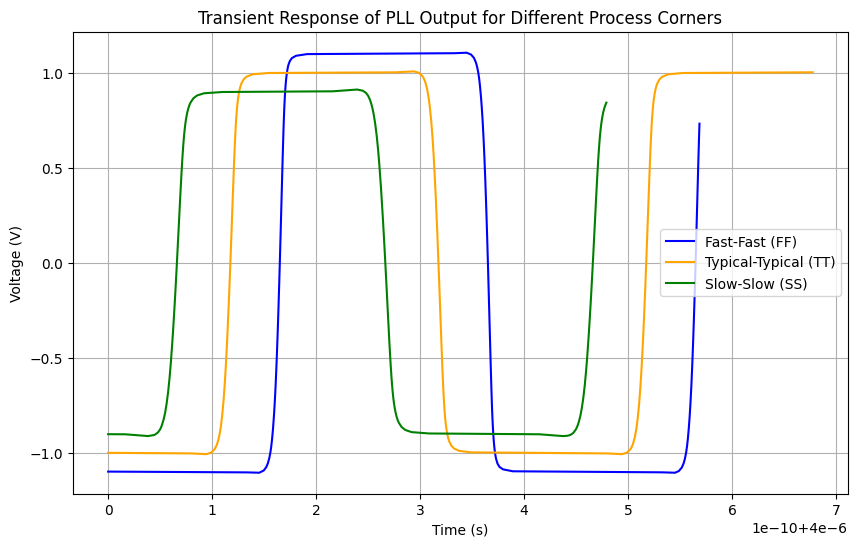

In [2]:
fosc = 2.5e9  # Oscillation frequency of the PLL in Hz
fref = 150e6  # Reference frequency in Hz

# Read the CSV file with specified column names
csv_path = 'C:/Users/adant/Mi unidad (atorralba@inaoe.mx)/Reportes/EDIESCA 2025/PostLayout2/tran_clk_ss_ff_tt_pex.csv'
df = pd.read_csv(csv_path, header=None, names=['time_ff', 'voltage_ff', 'time_tt', 'voltage_tt', 'time_ss', 'voltage_ss'])

# Replace whitespace-only strings with NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

# Generate arrays for each column, eliminating NaN (non-existing data)
time_ff = df['time_ff'].dropna().values
voltage_ff = df['voltage_ff'].dropna().values
time_tt = df['time_tt'].dropna().values
voltage_tt = df['voltage_tt'].dropna().values
time_ss = df['time_ss'].dropna().values
voltage_ss = df['voltage_ss'].dropna().values
# Convert string arrays to float arrays
t_ff = time_ff.astype(float)
v_ff = voltage_ff.astype(float)
t_tt = time_tt.astype(float)
v_tt = voltage_tt.astype(float)
t_ss = time_ss.astype(float)
v_ss = voltage_ss.astype(float)
# Print lengths of each array to verify
print(f"time_ff length: {len(t_ff)}")
print(f"v_ff length: {len(v_ff)}")
print(f"time_tt length: {len(t_tt)}")
print(f"v_tt length: {len(v_tt)}")
print(f"time_ss length: {len(t_ss)}")
print(f"v_ss length: {len(v_ss)}")


#plot only the first 100 samples the three signals just to verify they were read correctly
plt.figure(figsize=(10, 6))
plt.plot(t_ff[:100], v_ff[:100], label='Fast-Fast (FF)', color='blue')
plt.plot(t_tt[:100], v_tt[:100], label='Typical-Typical (TT)', color='orange')
plt.plot(t_ss[:100], v_ss[:100], label='Slow-Slow (SS)', color='green')
plt.title('Transient Response of PLL Output for Different Process Corners')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid(True) 
plt.show()

#Interpolate the three signals to have the same time base
steptime = 1e-12  # 1 ps time step
initial_time = min(t_ff[0], t_tt[0], t_ss[0])
final_time = max(t_ff[-1], t_tt[-1], t_ss[-1])
num_points = int((final_time - initial_time) / steptime) + 1


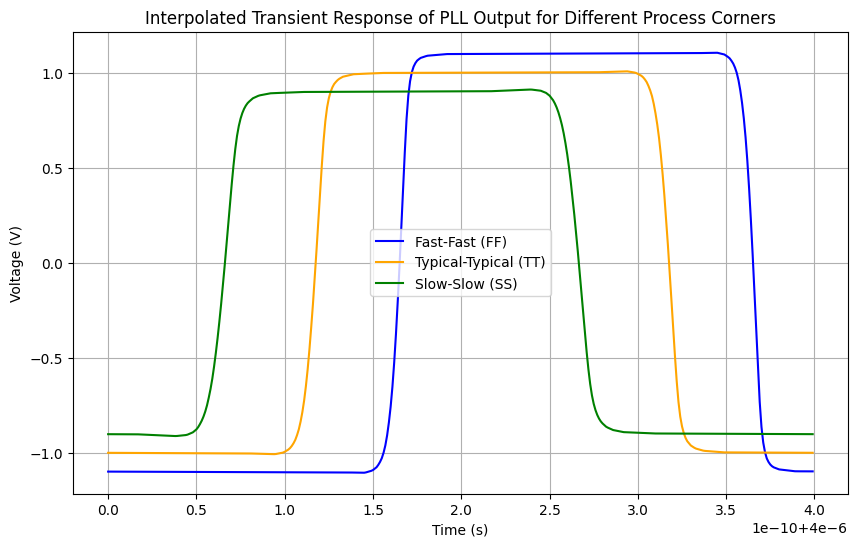

common_time length: 26000001
interp_v_ff length: 26000001
interp_v_tt length: 26000001
interp_v_ss length: 26000001


In [5]:
#Interpolate the three signals to have the same time base
steptime = 1e-12  # 1 ps time step
initial_time = min(t_ff[0], t_tt[0], t_ss[0])
final_time = max(t_ff[-1], t_tt[-1], t_ss[-1])
num_points = int((final_time - initial_time) / steptime) + 1

common_time = np.linspace(initial_time, final_time, num=num_points)
interp_v_ff = np.interp(common_time, t_ff, v_ff)
interp_v_tt = np.interp(common_time, t_tt, v_tt)
interp_v_ss = np.interp(common_time, t_ss, v_ss)


# plot the first 100 samples of the interpolated signals to verify interpolation
plt.figure(figsize=(10, 6))
plt.plot(common_time[:400], interp_v_ff[:400], label='Fast-Fast (FF)', color='blue')
plt.plot(common_time[:400], interp_v_tt[:400], label='Typical-Typical (TT)', color='orange')
plt.plot(common_time[:400], interp_v_ss[:400], label='Slow-Slow (SS)', color='green')
plt.title('Interpolated Transient Response of PLL Output for Different Process Corners')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid(True)
plt.show()

# save the interpolated signals to a new CSV file
interpolated_df = pd.DataFrame({
    'time': common_time,
    'voltage_ff': interp_v_ff,
    'voltage_tt': interp_v_tt,
    'voltage_ss': interp_v_ss
})
interpolated_df.to_csv('C:/Users/adant/Documents/interpolated_signals.csv', index=False)

# Print lengths of each new array to verify interpolation
print(f"common_time length: {len(common_time)}")
print(f"interp_v_ff length: {len(interp_v_ff)}")
print(f"interp_v_tt length: {len(interp_v_tt)}")
print(f"interp_v_ss length: {len(interp_v_ss)}")

In [3]:
# Load transient data from CSV files
csv_path = 'C:/Users/adant/Documents/interpolated_signals.csv'
df = pd.read_csv(csv_path)
common_time = df['time'].values
interp_v_tt = df['voltage_tt'].values
interp_v_ss = df['voltage_ss'].values
interp_v_ff = df['voltage_ff'].values

Maximum complete eye windows available: 65000


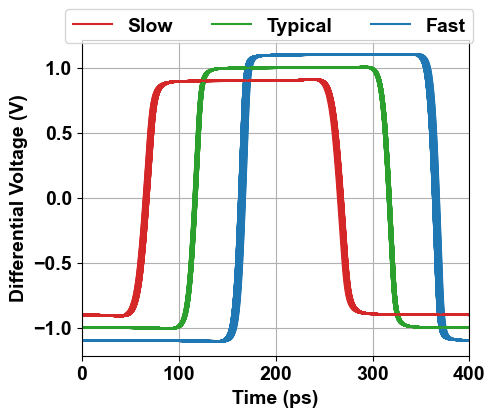

In [4]:
# Set font properties
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'


# Plot the eye diagram for the three signals over the first 10 reference periods
eye_window = 1 / fosc
available_duration = common_time[-1] - common_time[0]
max_eye_windows = int(np.floor(available_duration / eye_window))
print(f'Maximum complete eye windows available: {max_eye_windows}')

windows = 1000
#windows = max_eye_windows

fig, ax = plt.subplots(figsize=(5, 4))
for i in range(windows):
    start_time = initial_time + i * eye_window
    end_time = start_time + eye_window
    mask = (common_time >= start_time) & (common_time < end_time)
    ax.plot(
        (common_time[mask] - start_time) * 1e12,
        interp_v_ff[mask],
        color='tab:blue',
        label='Fast' if i == 0 else '_nolegend_',
    )
    ax.plot(
        (common_time[mask] - start_time) * 1e12,
        interp_v_tt[mask],
        color='tab:green',
        label='Typical' if i == 0 else '_nolegend_',
    )
    ax.plot(
        (common_time[mask] - start_time) * 1e12,
        interp_v_ss[mask],
        color='tab:red',
        label='Slow' if i == 0 else '_nolegend_',
    )

ax.set_xlabel('Time (ps)', fontweight='bold')
ax.set_ylabel('Differential Voltage (V)', fontweight='bold')
ax.set_xlim([0, 400])
ax.grid(True)
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles[::-1], labels[::-1],
    loc='upper center', bbox_to_anchor=(0.5, 1), ncol=3,
)
fig.subplots_adjust(top=0.9)
#plt.tight_layout()
plt.savefig('eyediagram_ff_ss_tt.png', dpi=400, bbox_inches='tight', pad_inches=0.1)
plt.show()